In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the main dataset
df = pd.read_csv("compressed_data.csv")
df

,MMM_TIMESERIES_ID,ORGANISATION_ID,ORGANISATION_VERTICAL,ORGANISATION_SUBVERTICAL,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,...,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,META_OTHER_IMPRESSIONS,TIKTOK_IMPRESSIONS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS
0,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,29-07-2022,USD,22,...,18997.0,NaN,NaN,NaN,139.0,NaN,300.0,1.0,61.0,40.0
1,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,30-07-2022,USD,14,...,20188.0,NaN,NaN,NaN,209.0,NaN,442.0,8.0,110.0,62.0
2,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,31-07-2022,USD,31,...,24718.0,NaN,NaN,NaN,262.0,NaN,427.0,631.0,108.0,65.0
3,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,01-08-2022,USD,18,...,25076.0,NaN,NaN,NaN,247.0,NaN,400.0,117.0,125.0,68.0
4,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,02-08-2022,USD,23,...,22688.0,NaN,NaN,NaN,255.0,NaN,425.0,37.0,146.0,65.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132754,21ae5756595080e735f52426db421505,ff5c2c32d7f1c21594c518fc6a6d4fce,Apparel,Other,"Google, Meta",US,All Territories,15-05-2024,USD,14,...,50550.0,NaN,NaN,NaN,294.0,204.0,234.0,1624.0,54.0,380.0
132755,21ae5756595080e735f52426db421505,ff5c2c32d7f1c21594c518fc6a6d4fce,Apparel,Other,"Google, Meta",US,All Territories,16-05-2024,USD,12,...,51024.0,NaN,NaN,NaN,206.0,212.0,209.0,225.0,48.0,335.0
132756,21ae5756595080e735f52426db421505,ff5c2c32d7f1c21594c518fc6a6d4fce,Apparel,Other,"Google, Meta",US,All Territories,17-05-2024,USD,7,...,41637.0,NaN,NaN,NaN,216.0,186.0,213.0,88.0,40.0,706.0
132757,21ae5756595080e735f52426db421505,ff5c2c32d7f1c21594c518fc6a6d4fce,Apparel,Other,"Google, Meta",US,All Territories,18-05-2024,USD,14,...,37661.0,NaN,NaN,NaN,951.0,169.0,190.0,167.0,37.0,366.0


In [4]:
# Quick check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 132759 entries, 0 to 132758
Data columns (total 50 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   MMM_TIMESERIES_ID                    132759 non-null  str    
 1   ORGANISATION_ID                      132759 non-null  str    
 2   ORGANISATION_VERTICAL                124649 non-null  str    
 3   ORGANISATION_SUBVERTICAL             124649 non-null  str    
 4   ORGANISATION_MARKETING_SOURCES       132759 non-null  str    
 5   ORGANISATION_PRIMARY_TERRITORY_NAME  132759 non-null  str    
 6   TERRITORY_NAME                       132759 non-null  str    
 7   DATE_DAY                             132759 non-null  str    
 8   CURRENCY_CODE                        132759 non-null  str    
 9   FIRST_PURCHASES                      132759 non-null  int64  
 10  FIRST_PURCHASES_UNITS                132759 non-null  int64  
 11  FIRST_PURCHASES_ORIGINAL

In [5]:
df.head()

,MMM_TIMESERIES_ID,ORGANISATION_ID,ORGANISATION_VERTICAL,ORGANISATION_SUBVERTICAL,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,...,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,META_OTHER_IMPRESSIONS,TIKTOK_IMPRESSIONS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS
0,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,29-07-2022,USD,22,...,18997.0,NaN,NaN,NaN,139.0,NaN,300.0,1.0,61.0,40.0
1,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,30-07-2022,USD,14,...,20188.0,NaN,NaN,NaN,209.0,NaN,442.0,8.0,110.0,62.0
2,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,31-07-2022,USD,31,...,24718.0,NaN,NaN,NaN,262.0,NaN,427.0,631.0,108.0,65.0
3,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,01-08-2022,USD,18,...,25076.0,NaN,NaN,NaN,247.0,NaN,400.0,117.0,125.0,68.0
4,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,02-08-2022,USD,23,...,22688.0,NaN,NaN,NaN,255.0,NaN,425.0,37.0,146.0,65.0


In [6]:
# Check null values summary (optional to visualize)
print(df.isnull().sum().sort_values(ascending=False))

TIKTOK_CLICKS                          129297
TIKTOK_SPEND                           129297
TIKTOK_IMPRESSIONS                     129297
GOOGLE_VIDEO_SPEND                     125131
GOOGLE_VIDEO_IMPRESSIONS               125131
GOOGLE_VIDEO_CLICKS                    125131
GOOGLE_DISPLAY_SPEND                   114013
GOOGLE_DISPLAY_CLICKS                  114013
GOOGLE_DISPLAY_IMPRESSIONS             114013
META_OTHER_CLICKS                      109214
META_OTHER_IMPRESSIONS                 109214
META_OTHER_SPEND                       109214
META_INSTAGRAM_SPEND                   105942
META_INSTAGRAM_CLICKS                  105942
META_INSTAGRAM_IMPRESSIONS             105942
GOOGLE_PMAX_CLICKS                      71633
GOOGLE_PMAX_SPEND                       71633
GOOGLE_PMAX_IMPRESSIONS                 71633
GOOGLE_SHOPPING_IMPRESSIONS             53779
GOOGLE_SHOPPING_CLICKS                  53779
GOOGLE_SHOPPING_SPEND                   53779
META_FACEBOOK_IMPRESSIONS         

In [7]:
# Drop irrelevant columns
drop_cols = [
    'TIKTOK_SPEND', 'TIKTOK_CLICKS', 'TIKTOK_IMPRESSIONS',
    'GOOGLE_VIDEO_SPEND', 'GOOGLE_VIDEO_CLICKS', 'GOOGLE_VIDEO_IMPRESSIONS',
    'GOOGLE_DISPLAY_SPEND', 'GOOGLE_DISPLAY_CLICKS', 'GOOGLE_DISPLAY_IMPRESSIONS',
    'META_OTHER_SPEND', 'META_OTHER_CLICKS', 'META_OTHER_IMPRESSIONS'
]
df.drop(columns=drop_cols, inplace=True)

In [8]:
# Fill missing values with zero
fill_zero_cols = [
    'GOOGLE_PAID_SEARCH_SPEND', 'GOOGLE_PAID_SEARCH_CLICKS', 'GOOGLE_PAID_SEARCH_IMPRESSIONS',
    'GOOGLE_SHOPPING_SPEND', 'GOOGLE_SHOPPING_CLICKS', 'GOOGLE_SHOPPING_IMPRESSIONS',
    'GOOGLE_PMAX_SPEND', 'GOOGLE_PMAX_CLICKS', 'GOOGLE_PMAX_IMPRESSIONS',
    'META_FACEBOOK_SPEND', 'META_FACEBOOK_CLICKS', 'META_FACEBOOK_IMPRESSIONS',
    'META_INSTAGRAM_SPEND', 'META_INSTAGRAM_CLICKS', 'META_INSTAGRAM_IMPRESSIONS',
    'BRANDED_SEARCH_CLICKS', 'DIRECT_CLICKS', 'EMAIL_CLICKS',
    'REFERRAL_CLICKS', 'ALL_OTHER_CLICKS', 'ORGANIC_SEARCH_CLICKS'
]
df[fill_zero_cols] = df[fill_zero_cols].fillna(0)

In [9]:
print("\n Missing values after cleaning:")
df.isnull().sum()


 Missing values after cleaning:


MMM_TIMESERIES_ID                         0
ORGANISATION_ID                           0
ORGANISATION_VERTICAL                  8110
ORGANISATION_SUBVERTICAL               8110
ORGANISATION_MARKETING_SOURCES            0
ORGANISATION_PRIMARY_TERRITORY_NAME       0
TERRITORY_NAME                            0
DATE_DAY                                  0
CURRENCY_CODE                             0
FIRST_PURCHASES                           0
FIRST_PURCHASES_UNITS                     0
FIRST_PURCHASES_ORIGINAL_PRICE            0
FIRST_PURCHASES_GROSS_DISCOUNT            0
ALL_PURCHASES                             0
ALL_PURCHASES_UNITS                       0
ALL_PURCHASES_ORIGINAL_PRICE              0
ALL_PURCHASES_GROSS_DISCOUNT              0
GOOGLE_PAID_SEARCH_SPEND                  0
GOOGLE_SHOPPING_SPEND                     0
GOOGLE_PMAX_SPEND                         0
META_FACEBOOK_SPEND                       0
META_INSTAGRAM_SPEND                      0
GOOGLE_PAID_SEARCH_CLICKS       

In [10]:
optional_meta_cols = ['MMM_TIMESERIES_ID', 'ORGANISATION_VERTICAL', 'ORGANISATION_SUBVERTICAL']
df.drop(columns=optional_meta_cols, inplace=True)

In [11]:
df.isnull().sum()

ORGANISATION_ID                        0
ORGANISATION_MARKETING_SOURCES         0
ORGANISATION_PRIMARY_TERRITORY_NAME    0
TERRITORY_NAME                         0
DATE_DAY                               0
CURRENCY_CODE                          0
FIRST_PURCHASES                        0
FIRST_PURCHASES_UNITS                  0
FIRST_PURCHASES_ORIGINAL_PRICE         0
FIRST_PURCHASES_GROSS_DISCOUNT         0
ALL_PURCHASES                          0
ALL_PURCHASES_UNITS                    0
ALL_PURCHASES_ORIGINAL_PRICE           0
ALL_PURCHASES_GROSS_DISCOUNT           0
GOOGLE_PAID_SEARCH_SPEND               0
GOOGLE_SHOPPING_SPEND                  0
GOOGLE_PMAX_SPEND                      0
META_FACEBOOK_SPEND                    0
META_INSTAGRAM_SPEND                   0
GOOGLE_PAID_SEARCH_CLICKS              0
GOOGLE_SHOPPING_CLICKS                 0
GOOGLE_PMAX_CLICKS                     0
META_FACEBOOK_CLICKS                   0
META_INSTAGRAM_CLICKS                  0
GOOGLE_PAID_SEAR

In [12]:
df

,ORGANISATION_ID,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,FIRST_PURCHASES_UNITS,FIRST_PURCHASES_ORIGINAL_PRICE,FIRST_PURCHASES_GROSS_DISCOUNT,...,GOOGLE_SHOPPING_IMPRESSIONS,GOOGLE_PMAX_IMPRESSIONS,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS
0,04769dac8b828ec7a85676d9e2bffe6f,"Google, Meta",US,All Territories,29-07-2022,USD,22,27,3837.980834,632.595555,...,0.0,31907.0,18997.0,0.0,139.0,0.0,300.0,1.0,61.0,40.0
1,04769dac8b828ec7a85676d9e2bffe6f,"Google, Meta",US,All Territories,30-07-2022,USD,14,21,2747.998631,443.996523,...,0.0,44483.0,20188.0,0.0,209.0,0.0,442.0,8.0,110.0,62.0
2,04769dac8b828ec7a85676d9e2bffe6f,"Google, Meta",US,All Territories,31-07-2022,USD,31,39,4567.998818,1185.197966,...,0.0,58173.0,24718.0,0.0,262.0,0.0,427.0,631.0,108.0,65.0
3,04769dac8b828ec7a85676d9e2bffe6f,"Google, Meta",US,All Territories,01-08-2022,USD,18,30,2878.982385,696.519993,...,0.0,55559.0,25076.0,0.0,247.0,0.0,400.0,117.0,125.0,68.0
4,04769dac8b828ec7a85676d9e2bffe6f,"Google, Meta",US,All Territories,02-08-2022,USD,23,27,3107.993669,627.097427,...,0.0,47854.0,22688.0,0.0,255.0,0.0,425.0,37.0,146.0,65.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132754,ff5c2c32d7f1c21594c518fc6a6d4fce,"Google, Meta",US,All Territories,15-05-2024,USD,14,102,5117.501854,140.000000,...,33.0,10786.0,50550.0,0.0,294.0,204.0,234.0,1624.0,54.0,380.0
132755,ff5c2c32d7f1c21594c518fc6a6d4fce,"Google, Meta",US,All Territories,16-05-2024,USD,12,61,4015.000000,250.510000,...,11.0,8274.0,51024.0,0.0,206.0,212.0,209.0,225.0,48.0,335.0
132756,ff5c2c32d7f1c21594c518fc6a6d4fce,"Google, Meta",US,All Territories,17-05-2024,USD,7,45,1132.500000,5.000000,...,6.0,14495.0,41637.0,0.0,216.0,186.0,213.0,88.0,40.0,706.0
132757,ff5c2c32d7f1c21594c518fc6a6d4fce,"Google, Meta",US,All Territories,18-05-2024,USD,14,113,3997.500000,50.500000,...,0.0,31355.0,37661.0,0.0,951.0,169.0,190.0,167.0,37.0,366.0


# # Feature Engineering & Preprocessing

## Convert DATE_DAY to datetime and Create Time Features

In [15]:
# Convert DATE_DAY to datetime
df['DATE_DAY'] = pd.to_datetime(df['DATE_DAY'])

In [16]:
# Sort data by Date
df = df.sort_values('DATE_DAY')

In [17]:
# Create time features
df['year'] = df['DATE_DAY'].dt.year
df['month'] = df['DATE_DAY'].dt.month
df['week'] = df['DATE_DAY'].dt.isocalendar().week
df['day_of_week'] = df['DATE_DAY'].dt.dayofweek

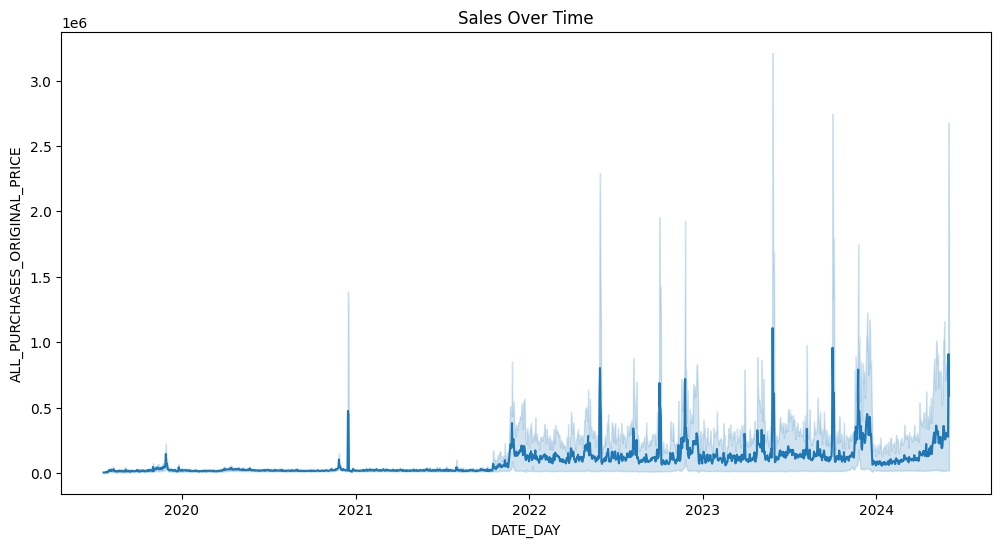

In [18]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='DATE_DAY', y='ALL_PURCHASES_ORIGINAL_PRICE')
plt.title("Sales Over Time")
plt.show()

# Create ROI-related features

In [19]:
# Create a new column 'revenue'
df['revenue'] = df['ALL_PURCHASES_ORIGINAL_PRICE'] - df['ALL_PURCHASES_GROSS_DISCOUNT']

In [20]:
df.head()

,ORGANISATION_ID,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,FIRST_PURCHASES_UNITS,FIRST_PURCHASES_ORIGINAL_PRICE,FIRST_PURCHASES_GROSS_DISCOUNT,...,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS,year,month,week,day_of_week,revenue
11211,0d1fc3f1715b0c65776780e7ad8ac7df,Google,UK,All Territories,2019-07-21,GBP,18,26,3207.120432,233.137508,...,0.0,2.0,3.0,0.0,2.0,2019,7,29,6,3066.336913
11212,0d1fc3f1715b0c65776780e7ad8ac7df,Google,UK,All Territories,2019-07-22,GBP,25,33,3038.609452,84.538390,...,0.0,16.0,0.0,0.0,12.0,2019,7,30,0,2954.071062
11213,0d1fc3f1715b0c65776780e7ad8ac7df,Google,UK,All Territories,2019-07-23,GBP,19,24,2388.545073,15.750041,...,0.0,6.0,0.0,2.0,2.0,2019,7,30,1,2372.795032
11214,0d1fc3f1715b0c65776780e7ad8ac7df,Google,UK,All Territories,2019-07-24,GBP,21,26,2898.101824,57.745678,...,0.0,13.0,4.0,0.0,10.0,2019,7,30,2,2983.466115
11215,0d1fc3f1715b0c65776780e7ad8ac7df,Google,UK,All Territories,2019-07-25,GBP,17,19,2228.808889,5.580983,...,0.0,34.0,2.0,9.0,8.0,2019,7,30,3,2223.227906


In [21]:
# Calculate Total Spend

df['total_spend'] = (
    df['GOOGLE_PAID_SEARCH_SPEND'] +
    df['GOOGLE_SHOPPING_SPEND'] +
    df['GOOGLE_PMAX_SPEND'] +
    df['META_FACEBOOK_SPEND'] +
    df['META_INSTAGRAM_SPEND']
)

In [22]:
# Calculate ROI
df['roi'] = df['revenue'] / (df['total_spend'] + 1)  # add 1 to avoid div-by-zero

In [23]:
df

,ORGANISATION_ID,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,FIRST_PURCHASES_UNITS,FIRST_PURCHASES_ORIGINAL_PRICE,FIRST_PURCHASES_GROSS_DISCOUNT,...,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS,year,month,week,day_of_week,revenue,total_spend,roi
11211,0d1fc3f1715b0c65776780e7ad8ac7df,Google,UK,All Territories,2019-07-21,GBP,18,26,3207.120432,233.137508,...,3.0,0.0,2.0,2019,7,29,6,3066.336913,86.953533,34.863147
11212,0d1fc3f1715b0c65776780e7ad8ac7df,Google,UK,All Territories,2019-07-22,GBP,25,33,3038.609452,84.538390,...,0.0,0.0,12.0,2019,7,30,0,2954.071062,87.497234,33.380377
11213,0d1fc3f1715b0c65776780e7ad8ac7df,Google,UK,All Territories,2019-07-23,GBP,19,24,2388.545073,15.750041,...,0.0,2.0,2.0,2019,7,30,1,2372.795032,85.995222,27.275004
11214,0d1fc3f1715b0c65776780e7ad8ac7df,Google,UK,All Territories,2019-07-24,GBP,21,26,2898.101824,57.745678,...,4.0,0.0,10.0,2019,7,30,2,2983.466115,95.609758,30.881623
11215,0d1fc3f1715b0c65776780e7ad8ac7df,Google,UK,All Territories,2019-07-25,GBP,17,19,2228.808889,5.580983,...,2.0,9.0,8.0,2019,7,30,3,2223.227906,73.758269,29.738890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77644,882ce7e286d66facc66518783e2192c7,"Google, Meta",UK,Spain,2024-06-02,EUR,8,11,2583.000000,176.750000,...,68.0,1074.0,99.0,2024,6,22,6,2585.850000,412.730000,6.250091
32493,3f4463f3b51fc2056b97766e2373747d,"Google, Meta",UK,All Territories,2024-06-02,GBP,20,126,1291.460000,55.390000,...,5.0,14.0,283.0,2024,6,22,6,2385.613089,112.520000,21.014914
109456,ba773ebd7ec0a08f1d042187d086ccb4,"Google, Meta",UK,Italy,2024-06-02,EUR,23,32,9362.060000,532.450000,...,115.0,1065.0,68.0,2024,6,22,6,10495.970000,417.090000,25.104571
69673,7a801df71696ceb035e3503253cb15cf,Google,Australia,All Territories,2024-06-02,AUD,128,150,4136.813557,0.000000,...,0.0,7.0,538.0,2024,6,22,6,4414.813557,2596.965450,1.699335


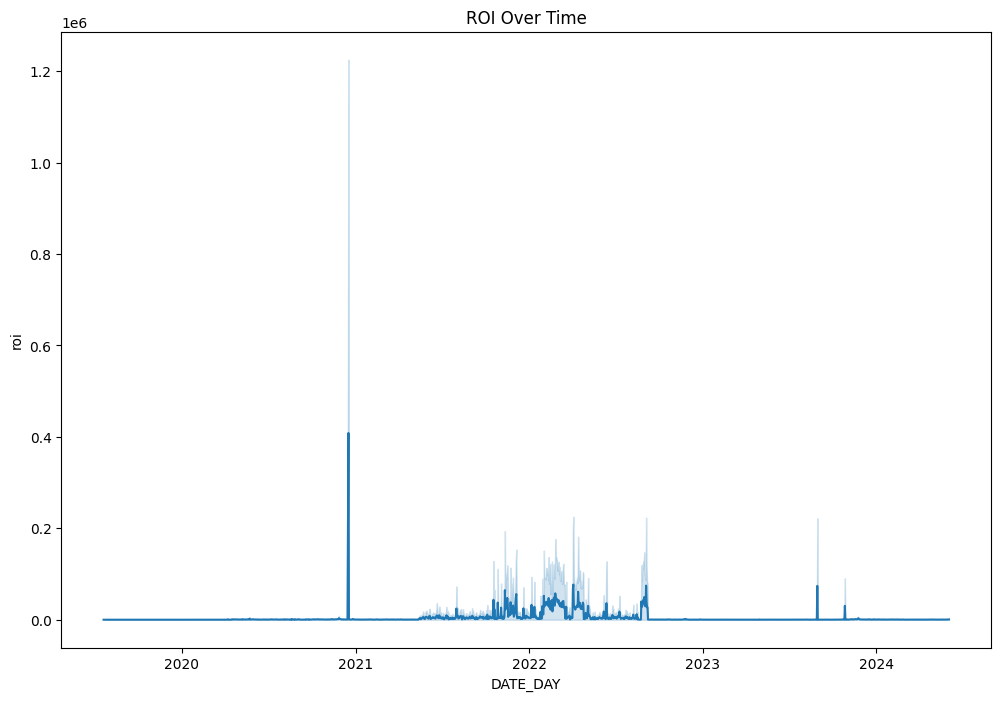

In [24]:
plt.figure(figsize=(12,8))
sns.lineplot(data=df, x='DATE_DAY', y='roi')
plt.title("ROI Over Time")
plt.show()

# Set the Target Variable and Input Features

In [25]:
target = 'revenue'

In [26]:
features = [
    'GOOGLE_PAID_SEARCH_SPEND', 'GOOGLE_SHOPPING_SPEND',
    'GOOGLE_PMAX_SPEND', 'META_FACEBOOK_SPEND', 'META_INSTAGRAM_SPEND',
    'EMAIL_CLICKS', 'ORGANIC_SEARCH_CLICKS', 'DIRECT_CLICKS',
    'BRANDED_SEARCH_CLICKS', 'year', 'month', 'day_of_week'
]

## Step 4: Train-Test Split

# Since this is time series data, we will use chronological split

In [27]:
# Sort by date
df = df.sort_values('DATE_DAY')

# Define cutoff date for time-based split
cutoff_date = '2023-12-31'  # Train on data up to end of 2023

# Train = everything before cutoff
train_df = df[df['DATE_DAY'] <= cutoff_date]

# Test = everything after cutoff
test_df = df[df['DATE_DAY'] > cutoff_date]

# Features and target
X_train = train_df[features]
y_train = train_df['revenue']
X_test = test_df[features]
y_test = test_df['revenue']

## Step 5: Model Training

In [28]:
# Linear Regression model (standard for MMM)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 6: Model Evaluation

In [29]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.7891499083056965
RMSE: 246748035379.61847


## Step 7: Feature Importance

## Linear models gives coefficients, which are ROI signals

In [30]:
importance = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_
}).sort_values(by='coefficient', ascending=False)

print(importance)

                     feature   coefficient
9                       year  19603.649446
10                     month   2600.523045
0   GOOGLE_PAID_SEARCH_SPEND     86.755994
5               EMAIL_CLICKS     80.479507
1      GOOGLE_SHOPPING_SPEND     46.873508
6      ORGANIC_SEARCH_CLICKS     34.919731
4       META_INSTAGRAM_SPEND     14.367582
3        META_FACEBOOK_SPEND      7.994609
8      BRANDED_SEARCH_CLICKS      5.154363
7              DIRECT_CLICKS    -19.450303
2          GOOGLE_PMAX_SPEND    -23.379289
11               day_of_week  -1347.359433


# Step 8: Budget Shift Simulation

In [31]:
scenario = X_test.copy()

In [32]:
# Simulate increased Google Ads, decreased TV
scenario['GOOGLE_PAID_SEARCH_SPEND'] *= 1.3  # +30%
# scenario['TV_SPEND'] *= 0.8  # if applicable

y_simulated = model.predict(scenario)

# Compare with actual predicted
change = ((y_simulated.mean() - y_pred.mean()) / y_pred.mean()) * 100
print(f"Simulated change in revenue: {change:.2f}%")

Simulated change in revenue: 4.60%


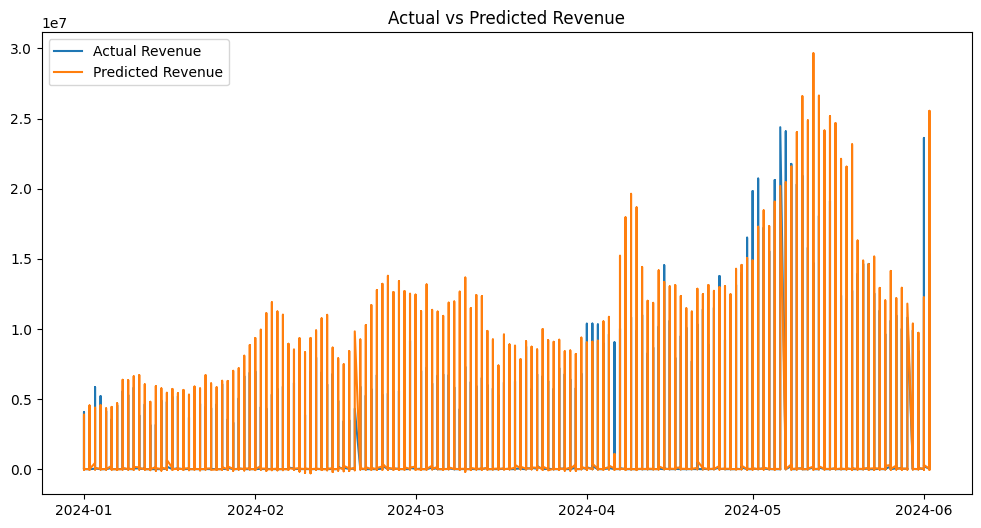

In [33]:
plt.figure(figsize=(12,6))
plt.plot(test_df['DATE_DAY'], y_test, label='Actual Revenue')
plt.plot(test_df['DATE_DAY'], y_pred, label='Predicted Revenue')
plt.title("Actual vs Predicted Revenue")
plt.legend()
plt.show()

## Step 9: Final Step

In [34]:
# Save the trained model

import joblib
joblib.dump(model, 'linear_mmm_model.pkl')

['linear_mmm_model.pkl']

In [35]:
# Save the features used for training
import json
with open('mmm_model_features.json', 'w') as f:
    json.dump(features, f)